In [1]:
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.build import build_dataset, build_loader
from src.train import load_train_config

In [2]:
CONFIG = ROOT / "config" / "model.yaml"
BATCH_SIZE = 6
AXES = ("axis 0", "axis 1", "axis 2")

In [3]:
cfg = load_train_config(CONFIG)
data = replace(cfg.data, batch_size=BATCH_SIZE, augment=False)

ds = build_dataset(data)
dl = build_loader(ds, data, device=torch.device("cpu"))
imgs, fracs, conds = next(iter(dl))

mean = [round(v, 4) for v in fracs.mean(dim=0).tolist()]
print(
    f"samples={len(ds)} batch={tuple(imgs.shape)} "
    f"axis_counts={torch.bincount(conds, minlength=3).tolist()} "
    f"fractions={mean}"
)

samples=9600 batch=(6, 1, 64, 64) axis_counts=[2, 2, 2] fractions=[0.5071, 0.095, 0.3979]


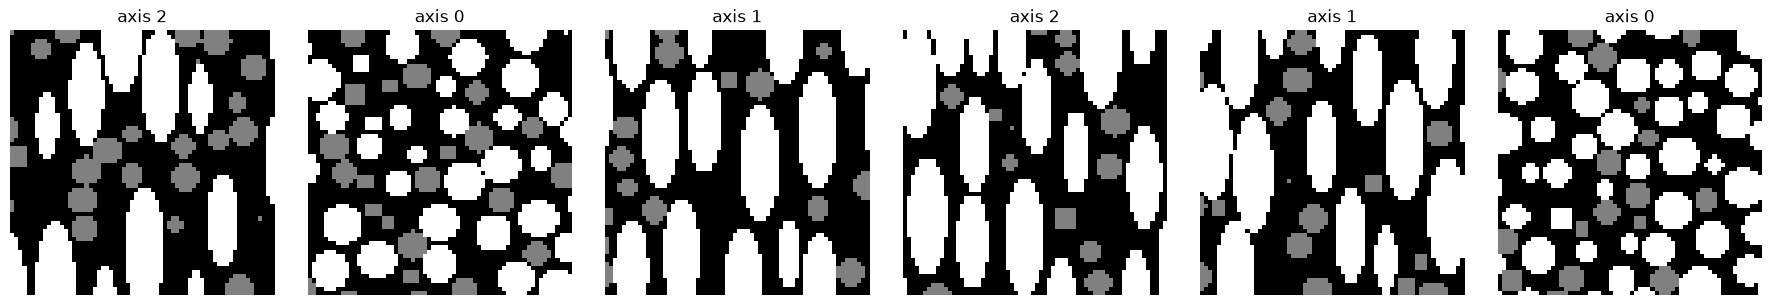

In [4]:
n = min(BATCH_SIZE, imgs.shape[0])
fig, axs = plt.subplots(1, n, figsize=(3 * n, 3), squeeze=False)
for ax, img, cond in zip(
    axs.ravel(), imgs[:n, 0], conds[:n]
):
    ax.imshow(
        img,
        cmap="gray",
        vmin=0,
        vmax=data.num_phases - 1,
        interpolation="nearest",
    )
    ax.set_title(AXES[int(cond)])
    ax.axis("off")
plt.tight_layout()